Roll Number: CH.SC.U4CSE24123
Name: M A Kaushik
RANDOM FORESTS 1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from collections import Counter
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)
n_samples = 100
apple_data = {
    'weight': np.random.normal(150, 15, n_samples // 2),
    'size': np.random.normal(7, 0.5, n_samples // 2),
    'color_score': np.random.normal(2, 0.3, n_samples // 2),
    'fruit': ['Apple'] * (n_samples // 2)
}
banana_data = {
    'weight': np.random.normal(120, 10, n_samples // 2),
    'size': np.random.normal(18, 1, n_samples // 2),
    'color_score': np.random.normal(1, 0.3, n_samples // 2),
    'fruit': ['Banana'] * (n_samples // 2)
}
df = pd.concat([pd.DataFrame(apple_data), pd.DataFrame(banana_data)], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle
df.head()

,weight,size,color_score,fruit
0,124.824724,17.348400,0.628655,Banana
1,122.322537,19.053802,1.309740,Banana
2,111.104856,20.314659,1.432382,Banana
3,139.202337,6.268243,2.234547,Apple
4,127.822170,6.803946,2.077965,Apple


In [ ]:
new_instance = pd.DataFrame({
    'weight': [145],
    'size': [7.2],
    'color_score': [1.9]
})
new_instance

,weight,size,color_score
0,145,7.2,1.9


In [ ]:
X = df[['weight', 'size', 'color_score']].values
y = df['fruit'].values
n_trees = 7
predictions = []
np.random.seed(1)
for i in range(n_trees):
    indices = np.random.choice(len(X), size=len(X), replace=True)
    X_sample, y_sample = X[indices], y[indices]
    tree = DecisionTreeClassifier(max_depth=3, random_state=i)
    tree.fit(X_sample, y_sample)
    pred = tree.predict(new_instance.values)[0]
    predictions.append(pred)
    print(f"Tree-{i+1} prediction: {pred}")

Tree-1 prediction: Apple
Tree-2 prediction: Apple
Tree-3 prediction: Apple
Tree-4 prediction: Apple
Tree-5 prediction: Apple
Tree-6 prediction: Apple
Tree-7 prediction: Apple


In [ ]:
vote_counts = Counter(predictions)
final_class = vote_counts.most_common(1)[0][0]
print(f"\nVotes: {dict(vote_counts)}")
print(f"Final Class (Majority Voting): {final_class}")


Votes: {'Apple': 7}
Final Class (Majority Voting): Apple


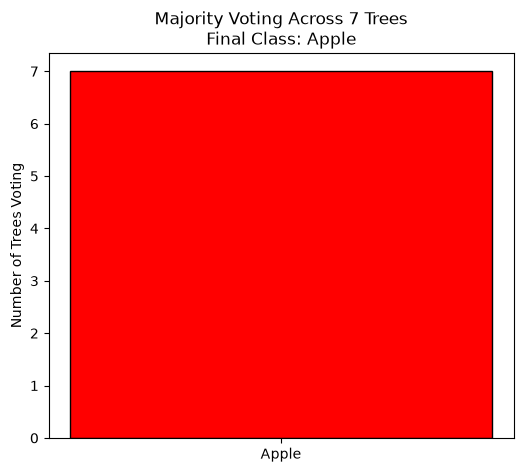

In [ ]:
plt.figure(figsize=(6, 5))
classes, counts = zip(*vote_counts.items())
colors = ['red' if c == 'Apple' else 'gold' for c in classes]
plt.bar(classes, counts, color=colors, edgecolor='k')
plt.ylabel('Number of Trees Voting')
plt.title(f'Majority Voting Across {n_trees} Trees\nFinal Class: {final_class}')
plt.show()